# Sequence similarity network from a FASTA file

This notebook builds a **sequence similarity network (SSN)** from a protein FASTA file. Each sequence is a node, each edge represents pairwise similarity above a user-defined threshold, and the resulting graph provides a direct view of local neighborhoods in sequence space.

The default input is `inputs/kras_homologs_10.fa`, but the same workflow can be used with any homologous protein FASTA file.



## Method

Let $S_1,\dots,S_n$ be the protein sequences in the FASTA file. For every pair $(i,j)$, the notebook computes a normalized alignment similarity
\[
w_{ij}=










rac{A(S_i,S_j)}{\sqrt{A(S_i,S_i)\,A(S_j,S_j)}},
\]
where $A(\cdot,\cdot)$ is the global alignment score returned by `Biopython PairwiseAligner` using **BLOSUM62** and affine gap penalties.

Given a similarity threshold $	au$, the SSN is the weighted graph
\[
G_	au=(V,E_	au), \qquad V=\{1,\dots,n\},
\]
with
\[
(i,j)\in E_	au \iff w_{ij}\ge 	au.
\]
The edge weight is $w_{ij}$ itself. Increasing $	au$ reveals finer-grained neighborhoods; decreasing $	au$ merges them into larger connected components.

If a FASTA header contains a field of the form `score=<value>`, the notebook reads that value from the full FASTA description and uses it as an optional node attribute. When the FASTA comes from the `ProteinMPNN` notebook, this `score=` field is the mean of 100 repeated `score_only` evaluations, so the SSN consumes a less noisy backbone-compatibility estimate directly from the FASTA header. The notebook also reads `original_score=` when present and prints a direct comparison before drawing the network. When the FASTA identifiers follow the ProteinMPNN convention `<entry>_<chain>_sample_k` or `<entry>_<chain>_native`, the notebook also infers a parent-structure group from the identifier and records the order in which each structure first appears in the generated FASTA file. In that case, the network uses a single node color, node transparency is driven by the ordered structure index, and node size is driven by the rank of the ProteinMPNN score so that the scale remains visually stable.

If no score is available, or if the identifiers do not match the ProteinMPNN naming scheme, the notebook falls back to the generic SSN coloring and still runs unchanged.

The layout uses a force-directed placement and the plot emphasizes threshold-defined neighborhoods rather than exact metric geometry.


## Requirements

This notebook uses `Biopython`, `networkx`, `numpy`, and `matplotlib`. If needed, install missing packages with:

```python
%pip install biopython networkx matplotlib
```


## Setup

This cell imports the required Python packages, defines the main input and output paths, and sets plotting or scoring parameters used throughout the notebook.

In [1]:
from pathlib import Path
from itertools import combinations
import csv
import math
import re

import matplotlib.pyplot as plt
from IPython.display import display
import networkx as nx
import numpy as np
from Bio import SeqIO
from Bio.Align import PairwiseAligner, substitution_matrices

# INPUT_FASTA = Path('inputs/kras_homologs_10.fa')
# INPUT_FASTA = Path('results/proteinmpnn/proteinmpnn_generated_sequences_design.fa')
INPUT_FASTA = Path('results/proteinmpnn/proteinmpnn_generated_sequences_reevaluated.fa')
# OUTPUT_PREFIX = Path('kras_ssn')
OUTPUT_PREFIX = Path('proteinmpnn_ssn')
FIGURES_DIR = Path('results/figures')
OUTPUT_PNG = FIGURES_DIR / 'sequenceTools_proteinmpnn_ssn.png'
OUTPUT_PDF = FIGURES_DIR / 'sequenceTools_proteinmpnn_ssn.pdf'
NODE_CSV = Path('results') / f'{OUTPUT_PREFIX.name}_nodes.csv'
EDGE_CSV = Path('results') / f'{OUTPUT_PREFIX.name}_edges.csv'
RANK_CSV = Path('results') / f'{OUTPUT_PREFIX.name}_pairwise_ranked_distances.csv'
HEATMAP_PNG = FIGURES_DIR / f'sequenceTools_{OUTPUT_PREFIX.name}_distance_heatmap.png'
HEATMAP_PDF = FIGURES_DIR / f'sequenceTools_{OUTPUT_PREFIX.name}_distance_heatmap.pdf'
SIMILARITY_THRESHOLD = 0.5

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ALIGNER = PairwiseAligner(mode='global')
ALIGNER.substitution_matrix = substitution_matrices.load('BLOSUM62')
ALIGNER.open_gap_score = -10.0
ALIGNER.extend_gap_score = -0.5

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## Helper Functions

This cell defines the helper functions used later in the workflow, including parsing routines, distance or similarity calculations, plotting helpers, and file-writing utilities.

In [2]:
def load_records(path: Path):
    records = list(SeqIO.parse(path, 'fasta'))
    if not records:
        raise ValueError(f'No FASTA records found in {path}')
    return records


def alignment_score(seq_a: str, seq_b: str) -> float:
    return float(ALIGNER.score(seq_a, seq_b))


def normalized_similarity(seq_a: str, seq_b: str) -> float:
    score_ab = alignment_score(seq_a, seq_b)
    score_aa = alignment_score(seq_a, seq_a)
    score_bb = alignment_score(seq_b, seq_b)
    scale = math.sqrt(max(score_aa, 1e-12) * max(score_bb, 1e-12))
    similarity = score_ab / scale
    return max(0.0, min(1.0, similarity))


def write_csv(path: Path, rows, fieldnames):
    with path.open('w', newline='') as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def short_label(record_id: str) -> str:
    return record_id.replace('KRAS_', '').replace('_P', '\nP')


def parse_named_float(description: str, key: str):
    token_prefix = f'{key}='
    for token in description.split():
        if token.startswith(token_prefix):
            try:
                return float(token.split('=', 1)[1].rstrip(','))
            except ValueError:
                return None
    return None


def proteinmpnn_group_key(record_id: str):
    match = re.match(r'(.+_[A-Za-z0-9]+)_(?:sample_\d+|native)$', record_id)
    return match.group(1) if match else None


def alpha_from_score(score: float, minimum: float, maximum: float) -> float:
    if maximum - minimum < 1e-12:
        return 1.0
    normalized = (score - minimum) / (maximum - minimum)
    return 0.25 + 0.75 * normalized


def blended_intensity(rgba):
    r, g, b, a = rgba
    r_eff = a * r + (1.0 - a)
    g_eff = a * g + (1.0 - a)
    b_eff = a * b + (1.0 - a)
    return 0.299 * r_eff + 0.587 * g_eff + 0.114 * b_eff



def print_ranked_rows(rows, title: str, limit: int = 10):
    print(title)
    if not rows:
        print('  no pairs')
        return
    print('  rank  seq_a                  seq_b                  similarity  distance')
    for row in rows[:limit]:
        print(
            f"  {row['rank']:>4}  {row['source'][:22]:<22} {row['target'][:22]:<22} "
            f"{row['similarity']:.4f}      {row['distance']:.4f}"
        )



def group_order_map(records):
    order = {}
    for record in records:
        group = proteinmpnn_group_key(record.id)
        if group is not None and group not in order:
            order[group] = len(order) + 1
    return order


def alpha_from_group_order(order_index: int, total_groups: int) -> float:
    if total_groups <= 1:
        return 1.0
    normalized = (order_index - 1) / (total_groups - 1)
    return 0.25 + 0.75 * normalized


def score_rank_map(metadata_by_node):
    scored = sorted(
        ((node, data['score']) for node, data in metadata_by_node.items() if data['score'] is not None),
        key=lambda item: (-item[1], item[0])
    )
    total = len(scored)
    ranks = {}
    for rank, (node, score) in enumerate(scored, start=1):
        if total <= 1:
            normalized = 1.0
        else:
            normalized = (total - rank) / (total - 1)
        ranks[node] = {
            'rank': rank,
            'score': score,
            'normalized': normalized,
            'size_scale': 0.45 + 2.35 * (normalized ** 1.75),
        }
    return ranks


def structure_order_label(group: str, order_map):
    if group is None:
        return 'No structure order'
    return f"S{order_map[group]}: {group}"


## Data Loading And Computation

This cell loads the input sequences, applies the main method of the notebook, and assembles the derived quantities that will be exported or plotted.

In [3]:
records = load_records(INPUT_FASTA)
group_order = group_order_map(records)
metadata_by_node = {
    record.id: {
        'description': record.description,
        'score': parse_named_float(record.description, 'score'),
        'original_score': parse_named_float(record.description, 'original_score'),
        'group': proteinmpnn_group_key(record.id),
        'group_order': group_order.get(proteinmpnn_group_key(record.id)),
    }
    for record in records
}
score_ranks = score_rank_map(metadata_by_node)

similarity_matrix = np.eye(len(records), dtype=float)
pair_rows = []
edge_rows = []
G = nx.Graph()

for record in records:
    node_id = record.id
    metadata = metadata_by_node[node_id]
    G.add_node(
        node_id,
        description=metadata['description'],
        score=metadata['score'],
        original_score=metadata['original_score'],
        group=metadata['group'],
    )

for (i, record_i), (j, record_j) in combinations(enumerate(records), 2):
    similarity = normalized_similarity(str(record_i.seq), str(record_j.seq))
    distance = 1.0 - similarity
    similarity_matrix[i, j] = similarity
    similarity_matrix[j, i] = similarity
    pair_rows.append({
        'source': record_i.id,
        'target': record_j.id,
        'similarity': float(similarity),
        'distance': float(distance),
    })
    if similarity >= SIMILARITY_THRESHOLD:
        G.add_edge(record_i.id, record_j.id, weight=similarity)
        edge_rows.append({
            'source': record_i.id,
            'target': record_j.id,
            'similarity': float(similarity),
        })

components = list(nx.connected_components(G))
component_index = {}
for idx, component in enumerate(components, start=1):
    for node in component:
        component_index[node] = idx

node_rows = []
for node in G.nodes():
    degree = G.degree(node)
    weighted_degree = sum(data['weight'] for _, _, data in G.edges(node, data=True))
    node_rows.append({
        'node': node,
        'description': metadata_by_node[node]['description'],
        'group': metadata_by_node[node]['group'],
        'group_order': metadata_by_node[node]['group_order'],
        'score_rank': score_ranks[node]['rank'] if node in score_ranks else None,
        'component': component_index[node],
        'degree': degree,
        'weighted_degree': float(weighted_degree),
        'score': metadata_by_node[node]['score'],
        'original_score': metadata_by_node[node]['original_score'],
        'score_shift': (metadata_by_node[node]['score'] - metadata_by_node[node]['original_score']) if metadata_by_node[node]['score'] is not None and metadata_by_node[node]['original_score'] is not None else None,
    })

pair_rows = sorted(pair_rows, key=lambda row: (-row['similarity'], row['source'], row['target']))
for rank, row in enumerate(pair_rows, start=1):
    row['rank'] = rank
write_csv(NODE_CSV, node_rows, ['node', 'description', 'group', 'group_order', 'score_rank', 'component', 'degree', 'weighted_degree', 'score', 'original_score', 'score_shift'])
write_csv(EDGE_CSV, edge_rows, ['source', 'target', 'similarity'])
write_csv(RANK_CSV, pair_rows, ['rank', 'source', 'target', 'similarity', 'distance'])

num_scored = sum(item['score'] is not None for item in metadata_by_node.values())
num_original_scored = sum(item['original_score'] is not None for item in metadata_by_node.values())
num_grouped = sum(item['group'] is not None for item in metadata_by_node.values())
print(f'Sequences: {len(records)}')
print(f'Edges at threshold {SIMILARITY_THRESHOLD:.2f}: {G.number_of_edges()}')
print(f'Connected components: {len(components)}')
print(f'Sequences with score in FASTA header: {num_scored}')
print(f'Sequences with original_score in FASTA header: {num_original_scored}')
print(f'Sequences with ProteinMPNN-like group labels: {num_grouped}')
print(f'Saved node table: {NODE_CSV}')
print(f'Saved edge table: {EDGE_CSV}')
print(f'Saved ranked pair table: {RANK_CSV}')

comparison_rows = [
    {
        'node': node,
        'score': data['score'],
        'original_score': data['original_score'],
        'score_shift': data['score'] - data['original_score'],
    }
    for node, data in metadata_by_node.items()
    if data['score'] is not None and data['original_score'] is not None
]
comparison_rows = sorted(comparison_rows, key=lambda row: row['score_shift'], reverse=True)
if comparison_rows:
    print('\nProteinMPNN score comparison: original one-pass score vs 100-run re-evaluated score')
    print('  node                    original   reevaluated   shift')
    for row in comparison_rows[:10]:
        print(f"  {row['node'][:22]:<22} {row['original_score']:.4f}     {row['score']:.4f}      {row['score_shift']:+.4f}")
    mean_shift = sum(row['score_shift'] for row in comparison_rows) / len(comparison_rows)
    print(f'Average score shift: {mean_shift:+.4f}')


Sequences: 30
Edges at threshold 0.50: 195
Connected components: 1
Sequences with score in FASTA header: 30
Sequences with original_score in FASTA header: 20
Sequences with ProteinMPNN-like group labels: 30
Saved node table: results/proteinmpnn_ssn_nodes.csv
Saved edge table: results/proteinmpnn_ssn_edges.csv
Saved ranked pair table: results/proteinmpnn_ssn_pairwise_ranked_distances.csv

ProteinMPNN score comparison: original one-pass score vs 100-run re-evaluated score
  node                    original   reevaluated   shift
  8BLR_A_sample_2        0.8609     0.9607      +0.0998
  8BLR_A_sample_1        0.8714     0.9693      +0.0979
  8T73_A_sample_1        0.7809     0.8692      +0.0883
  8T75_A_sample_1        0.8517     0.9387      +0.0870
  8CPR_A_sample_1        0.8353     0.9182      +0.0829
  8JGD_A_sample_2        0.8337     0.9164      +0.0827
  7VVB_A_sample_1        0.8582     0.9405      +0.0823
  8JHL_A_sample_2        0.8339     0.9149      +0.0810
  8T71_A_sample_1   

## Cutoff Selection Aid

This step ranks all pairwise similarities and corresponding distances before drawing the SSN. Use the ranked table, the empirical quantiles, and the distance heatmap below to choose a reasonable cutoff for `SIMILARITY_THRESHOLD`.

In [4]:
pair_similarities = np.array([row['similarity'] for row in pair_rows], dtype=float)
quantile_levels = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
quantiles = np.quantile(pair_similarities, quantile_levels)

summary_rows = [
    {
        'quantile': level,
        'similarity': float(value),
        'distance': float(1.0 - value),
    }
    for level, value in zip(quantile_levels, quantiles)
]

print(f'Pairwise comparisons: {len(pair_rows)}')
print('Empirical similarity quantiles (useful as candidate SSN cutoffs):')
for row in summary_rows:
    print(
        f"  q={row['quantile']:>4.2f}  similarity={row['similarity']:.4f}  distance={row['distance']:.4f}"
    )

print()
print_ranked_rows(pair_rows[:10], 'Top similarities (smallest distances):', limit=10)
print()
print_ranked_rows(list(reversed(pair_rows))[:10], 'Lowest similarities (largest distances):', limit=10)
print()
closest_to_threshold = sorted(
    pair_rows,
    key=lambda row: (abs(row['similarity'] - SIMILARITY_THRESHOLD), -row['similarity'])
)
print_ranked_rows(closest_to_threshold[:10], f'Pairs closest to the current threshold {SIMILARITY_THRESHOLD:.2f}:', limit=10)
print()
print(f'Use the CSV {RANK_CSV} if you want to sort or filter the complete ranking outside the notebook.')


Pairwise comparisons: 435
Empirical similarity quantiles (useful as candidate SSN cutoffs):
  q=0.00  similarity=0.3621  distance=0.6379
  q=0.10  similarity=0.4083  distance=0.5917
  q=0.25  similarity=0.4284  distance=0.5716
  q=0.50  similarity=0.4916  distance=0.5084
  q=0.75  similarity=0.5471  distance=0.4529
  q=0.90  similarity=0.9328  distance=0.0672
  q=0.95  similarity=0.9633  distance=0.0367
  q=0.99  similarity=0.9834  distance=0.0166
  q=1.00  similarity=1.0000  distance=0.0000

Top similarities (smallest distances):
  rank  seq_a                  seq_b                  similarity  distance
     1  8BLR_A_native          8CPR_A_native          1.0000      0.0000
     2  8T74_A_native          8T75_A_native          1.0000      0.0000
     3  8JHL_A_native          8JGD_A_native          0.9880      0.0120
     4  8T71_A_native          8T74_A_native          0.9863      0.0137
     5  8T71_A_native          8T75_A_native          0.9863      0.0137
     6  8T74_A_native  

## Distance Heatmap

This step visualizes the full pairwise distance matrix before the network is drawn. Use the block structure, bright and dark regions, and the ranked pair table to choose a sensible SSN cutoff.

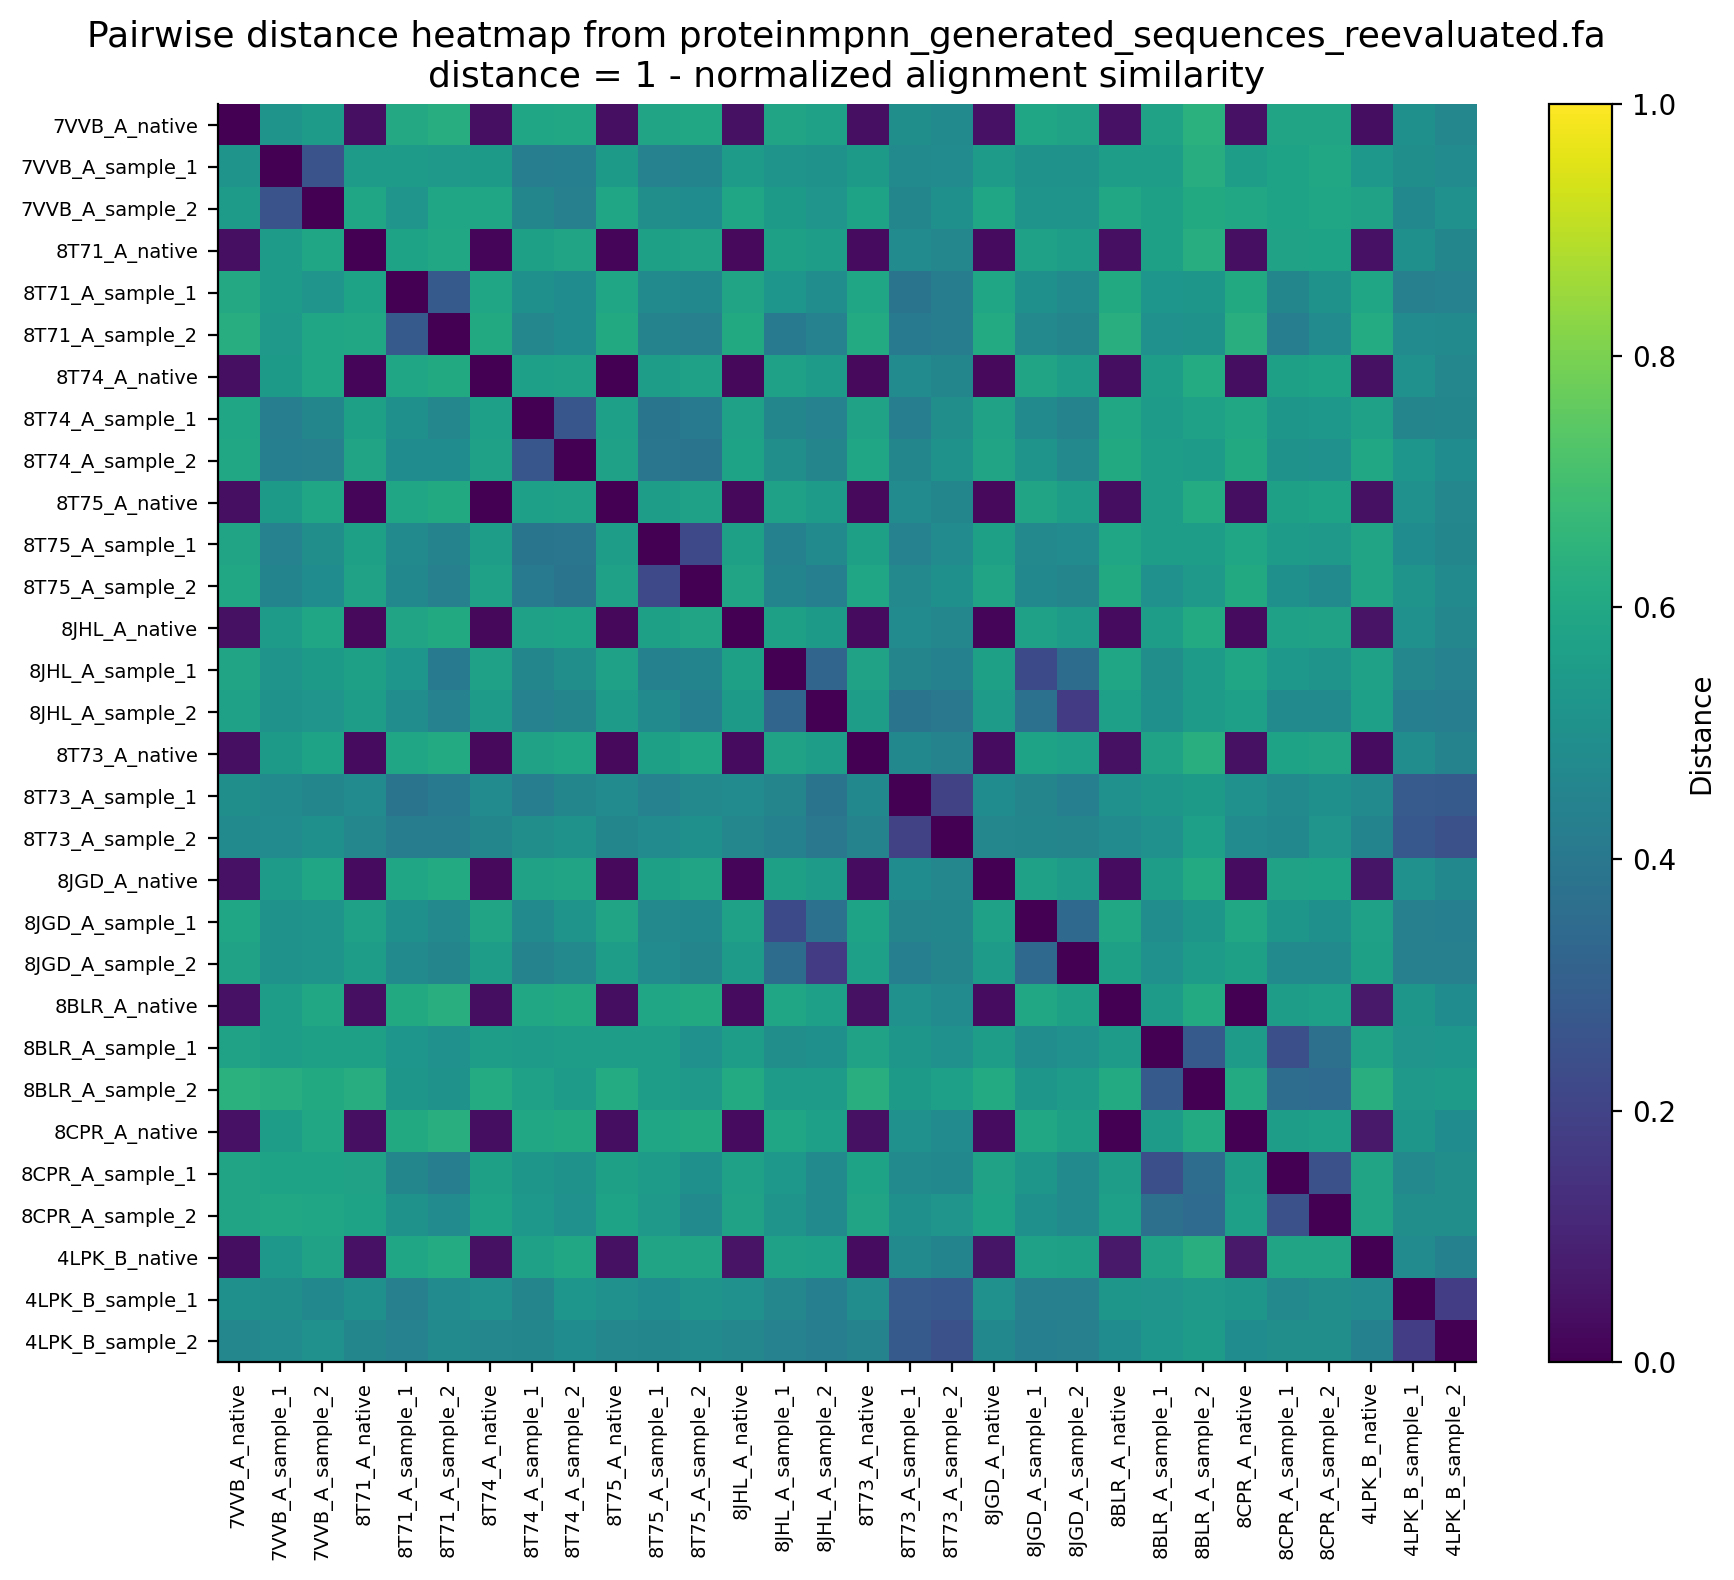

Saved distance heatmap: results/figures/sequenceTools_proteinmpnn_ssn_distance_heatmap.png
Saved distance heatmap: results/figures/sequenceTools_proteinmpnn_ssn_distance_heatmap.pdf


In [5]:
distance_matrix = 1.0 - similarity_matrix
ordered_nodes = sorted(
    G.nodes(),
    key=lambda node: (
        component_index[node],
        metadata_by_node[node]['group_order'] or 999,
        metadata_by_node[node]['group'] or '',
        node,
    ),
)
index_map = {record.id: idx for idx, record in enumerate(records)}
ordered_indices = [index_map[node] for node in ordered_nodes]
ordered_distance_matrix = distance_matrix[np.ix_(ordered_indices, ordered_indices)]

fig, ax = plt.subplots(figsize=(10, 8), dpi=200)
image = ax.imshow(ordered_distance_matrix, cmap='viridis', vmin=0.0, vmax=1.0)
ax.set_xticks(range(len(ordered_nodes)))
ax.set_yticks(range(len(ordered_nodes)))
ax.set_xticklabels([short_label(node) for node in ordered_nodes], rotation=90, fontsize=7)
ax.set_yticklabels([short_label(node) for node in ordered_nodes], fontsize=7)
ax.set_title(
    f'Pairwise distance heatmap from {INPUT_FASTA.name}\n'
    'distance = 1 - normalized alignment similarity',
    fontsize=13,
)
colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label('Distance')
fig.tight_layout()
fig.savefig(HEATMAP_PNG, dpi=300, bbox_inches='tight')
fig.savefig(HEATMAP_PDF, bbox_inches='tight')
plt.show()

print(f'Saved distance heatmap: {HEATMAP_PNG}')
print(f'Saved distance heatmap: {HEATMAP_PDF}')


## Visualization

This cell builds the final figure, applies the notebook-specific visual encoding, and writes the plot to the configured output files.

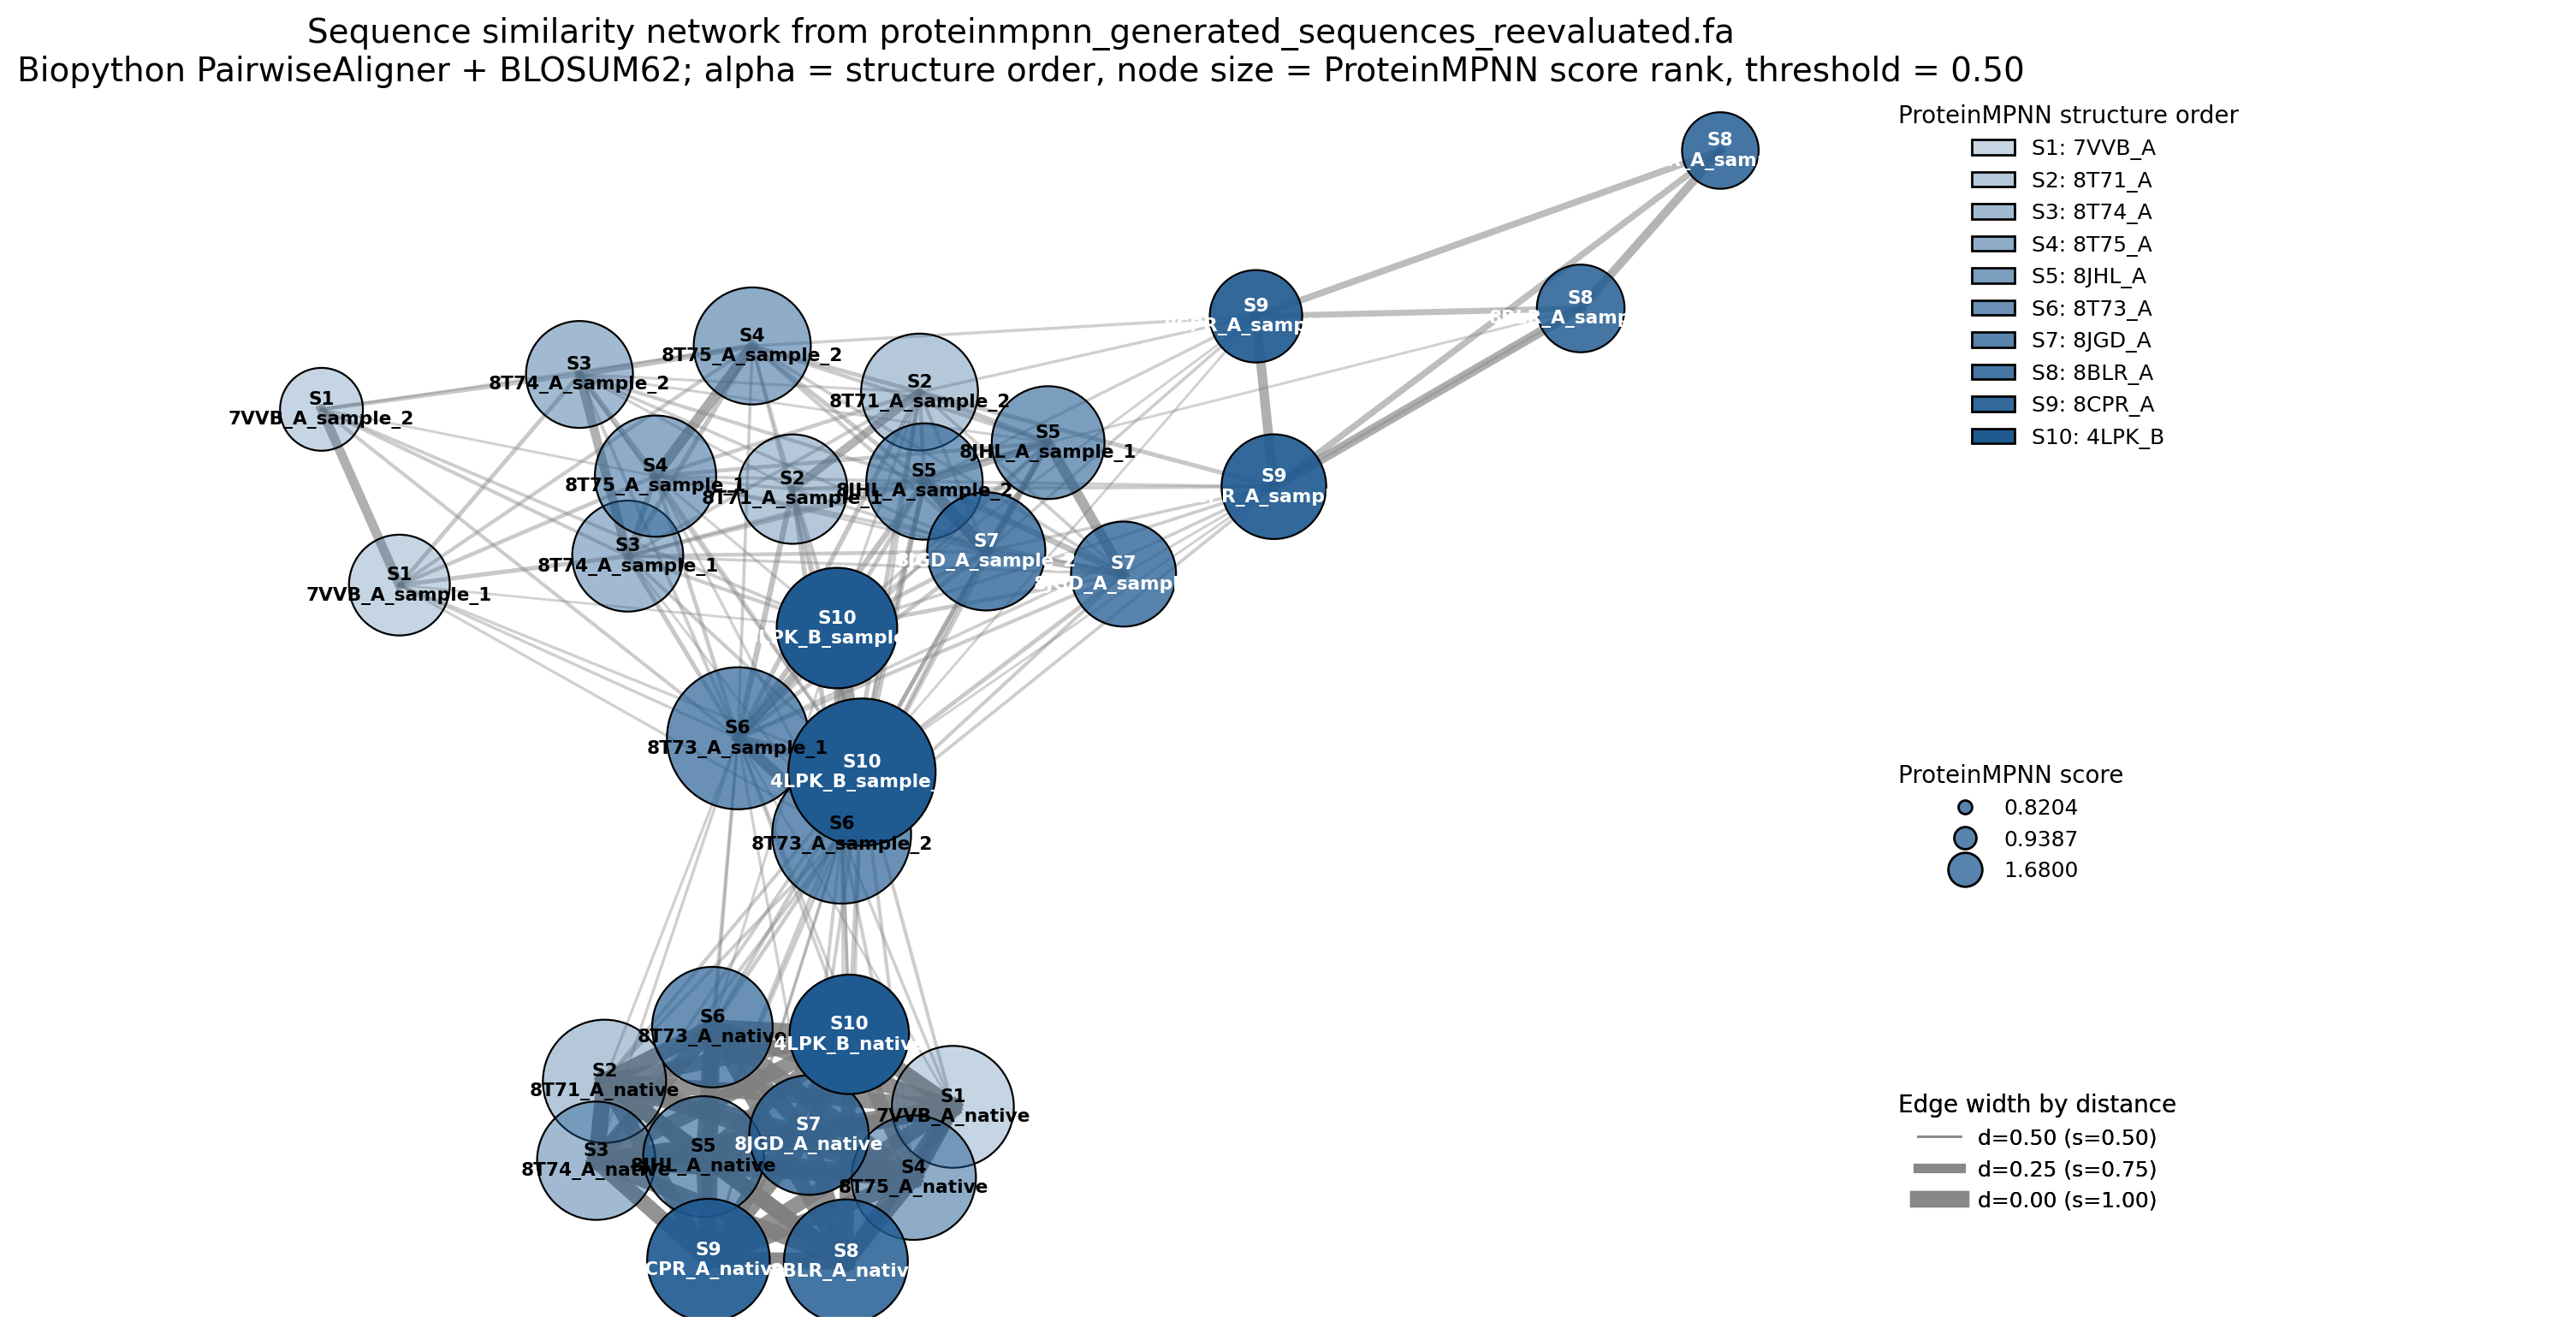

Saved figure: results/figures/sequenceTools_proteinmpnn_ssn.png
Saved figure: results/figures/sequenceTools_proteinmpnn_ssn.pdf


In [6]:
from matplotlib import colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(14.5, 8.5), dpi=200)
ax = fig.add_axes([0.05, 0.08, 0.62, 0.84])
legend_ax = fig.add_axes([0.71, 0.08, 0.27, 0.84])
legend_ax.axis('off')

positions = nx.spring_layout(G, seed=7, weight='weight', k=1.1 / max(len(G), 2) ** 0.5, iterations=300)
component_palette = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e', '#8c564b', '#17becf', '#e377c2']
base_single_color = mcolors.to_rgba('#1f5a91', alpha=1.0)
base_node_size = 420
edge_widths = [1.0 + 6.0 * (data['weight'] - SIMILARITY_THRESHOLD) / max(1e-6, 1.0 - SIMILARITY_THRESHOLD) for _, _, data in G.edges(data=True)]
edge_alphas = [0.35 + 0.55 * (data['weight'] - SIMILARITY_THRESHOLD) / max(1e-6, 1.0 - SIMILARITY_THRESHOLD) for _, _, data in G.edges(data=True)]

grouped_nodes = {node: metadata['group'] for node, metadata in metadata_by_node.items() if metadata['group'] is not None}
use_group_coloring = bool(grouped_nodes)
total_groups = len(group_order)
score_values = sorted(item['score'] for item in score_ranks.values())

node_sizes = []
node_colors = []
text_colors = []
for node in G.nodes():
    metadata = metadata_by_node[node]
    group = metadata['group']
    group_order_index = metadata['group_order']
    if node in score_ranks:
        node_size = base_node_size * score_ranks[node]['size_scale'] + 140 * G.degree(node)
    else:
        node_size = base_node_size + 140 * G.degree(node)
    node_sizes.append(node_size)

    if use_group_coloring and group is not None and group_order_index is not None:
        alpha = alpha_from_group_order(group_order_index, total_groups)
        rgba = (base_single_color[0], base_single_color[1], base_single_color[2], alpha)
        node_colors.append(rgba)
        intensity = blended_intensity(rgba)
        text_colors.append('white' if intensity < 0.52 else 'black')
    else:
        base = mcolors.to_rgba(component_palette[(component_index[node] - 1) % len(component_palette)], alpha=1.0)
        node_colors.append(base)
        intensity = blended_intensity(base)
        text_colors.append('white' if intensity < 0.52 else 'black')

for (u, v, data), width, alpha in zip(G.edges(data=True), edge_widths, edge_alphas):
    x0, y0 = positions[u]
    x1, y1 = positions[v]
    ax.plot([x0, x1], [y0, y1], color='#808080', linewidth=width, alpha=alpha, zorder=1)

nx.draw_networkx_nodes(G, positions, node_color=node_colors, node_size=node_sizes, edgecolors='black', linewidths=0.8, ax=ax)
for (node, (x_coord, y_coord)), text_color in zip(positions.items(), text_colors):
    metadata = metadata_by_node[node]
    if use_group_coloring and metadata['group_order'] is not None:
        label = f"S{metadata['group_order']}\n{short_label(node)}"
    else:
        label = short_label(node)
    ax.text(x_coord, y_coord, label, ha='center', va='center', fontsize=7.8, color=text_color, fontweight='bold', zorder=3)

if use_group_coloring and group_order:
    structure_handles = [
        Patch(
            facecolor=(base_single_color[0], base_single_color[1], base_single_color[2], alpha_from_group_order(order_index, total_groups)),
            edgecolor='black',
            label=structure_order_label(group, group_order),
        )
        for group, order_index in group_order.items()
    ]
    structure_legend = legend_ax.legend(
        handles=structure_handles,
        title='ProteinMPNN structure order',
        loc='upper left',
        bbox_to_anchor=(0.0, 1.0),
        frameon=False,
        borderaxespad=0.0,
        fontsize=9,
        title_fontsize=10,
    )
    legend_ax.add_artist(structure_legend)

if score_values:
    representative_scores = sorted({
        round(score_values[0], 4),
        round(score_values[len(score_values) // 2], 4),
        round(score_values[-1], 4),
    })
    size_handles = []
    for score_value in representative_scores:
        nearest_node = min(score_ranks, key=lambda node: abs(score_ranks[node]['score'] - score_value))
        marker_size = (base_node_size * score_ranks[nearest_node]['size_scale']) ** 0.5
        size_handles.append(
            Line2D(
                [], [],
                linestyle='',
                marker='o',
                markersize=marker_size / 2.4,
                markerfacecolor=(base_single_color[0], base_single_color[1], base_single_color[2], 0.75),
                markeredgecolor='black',
                label=f'{score_value:.4f}',
            )
        )
    size_legend = legend_ax.legend(
        handles=size_handles,
        title='ProteinMPNN score',
        loc='upper left',
        bbox_to_anchor=(0.0, 0.46),
        frameon=False,
        borderaxespad=0.0,
        fontsize=9,
        title_fontsize=10,
    )
    legend_ax.add_artist(size_legend)

if edge_widths:
    edge_similarity_levels = sorted({
        round(SIMILARITY_THRESHOLD, 2),
        round((SIMILARITY_THRESHOLD + 1.0) / 2.0, 2),
        1.0,
    })
    edge_handles = []
    for similarity_level in edge_similarity_levels:
        width = 1.0 + 6.0 * (similarity_level - SIMILARITY_THRESHOLD) / max(1e-6, 1.0 - SIMILARITY_THRESHOLD)
        distance_level = 1.0 - similarity_level
        edge_handles.append(
            Line2D([0], [0], color='#808080', linewidth=width, alpha=0.75, label=f'd={distance_level:.2f} (s={similarity_level:.2f})')
        )
    edge_legend = legend_ax.legend(
        handles=edge_handles,
        title='Edge width by distance',
        loc='upper left',
        bbox_to_anchor=(0.0, 0.19),
        frameon=False,
        borderaxespad=0.0,
        fontsize=9,
        title_fontsize=10,
    )
    legend_ax.add_artist(edge_legend)

subtitle = 'Biopython PairwiseAligner + BLOSUM62'
if use_group_coloring and score_ranks:
    subtitle += '; alpha = structure order, node size = ProteinMPNN score rank'
elif use_group_coloring:
    subtitle += '; alpha = structure order'

ax.set_title(
    f'Sequence similarity network from {INPUT_FASTA.name}\n'
    f'{subtitle}, threshold = {SIMILARITY_THRESHOLD:.2f}',
    fontsize=14,
)
ax.axis('off')
fig.savefig(OUTPUT_PNG, dpi=300)
fig.savefig(OUTPUT_PDF)
plt.show()

print(f'Saved figure: {OUTPUT_PNG}')
print(f'Saved figure: {OUTPUT_PDF}')



## Interpretation

An SSN is especially useful when the question is about **local neighborhoods** and **cluster structure** in sequence space rather than exact low-dimensional geometry. Connected components and dense subnetworks often highlight candidate subfamilies, iso-functional groups, or threshold-dependent transitions between them.

The graph depends strongly on the similarity definition and on the threshold. It should therefore be interpreted as a **filtered similarity graph**, not as a phylogenetic tree and not as a metric embedding.

If `score=<value>` is present in the FASTA header and the identifiers follow the ProteinMPNN naming convention, the plot overlays three extra pieces of information directly on the network: the ProteinMPNN score, typically the 100-run re-evaluated mean produced by the ProteinMPNN notebook, controls node size; the order of the original structures in the generated FASTA file is encoded through node transparency and explicit `S1`, `S2`, ... labels; and the structure groups are retained in the legend. Without score annotations, the notebook falls back to the default SSN coloring and still runs normally.
